# Chemical Physics: Arrhenius Activation Energy Inference

Infer an activation energy from sparse concentration measurements across temperatures using quantum Gaussian-process and quantum kernel regression.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Estimate an Arrhenius activation energy from finite-time concentration decay measurements taken at several temperatures.

**Explicit variables.** `activation_energy` is the target parameter, `temperatures` are experimental conditions, and `qgpr_energy_pred` contains quantum-GPR activation-energy estimates.

**Quantum advantage context.** Quantum kernels can act as nonlinear covariance models for inverse chemical-physics problems where parameters are observed only through transformed measurement traces. The notebook compares quantum regressors with ridge regression.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

The notebook uses a first-order reaction rate `k(T) = A exp(-Ea / RT)` and observes the remaining reactant concentration `C(t) = exp(-k(T)t)` at several temperatures.

In [2]:
def concentration_trace(activation_energy, temperatures, *, prefactor=4.0, gas_constant=8.314e-3, time=1.4):
    rates = prefactor * np.exp(-activation_energy / (gas_constant * temperatures))
    return np.exp(-rates * time)

rng = np.random.default_rng(831)
n_samples = 38
temperatures = np.asarray([295.0, 315.0, 335.0, 355.0, 375.0])
activation_energy = rng.uniform(7.5, 18.0, size=n_samples)
concentrations = np.asarray([concentration_trace(ea, temperatures) for ea in activation_energy])
concentrations += rng.normal(0.0, 0.006, size=concentrations.shape)
concentrations = np.clip(concentrations, 0.0, 1.0)

x_train, x_test, ea_train, ea_test = train_test_split(
    concentrations, activation_energy, test_size=0.3, random_state=831
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(ea_train.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(ea_test.reshape(-1, 1)).ravel()

print_section(
    "Dataset",
    [
        ("Problem", "Arrhenius activation energy inference"),
        ("Samples", n_samples),
        ("Features", [f"C(T={temp:.0f} K)" for temp in temperatures]),
        ("Target", "activation energy Ea"),
    ],
)


Dataset
+----------+--------------------------------------------------------------+
| Metric   | Value                                                        |
+----------+--------------------------------------------------------------+
| Problem  | Arrhenius activation energy inference                        |
| Samples  | 38                                                           |
| Features | [C(T=295 K), C(T=315 K), C(T=335 K), C(T=355 K), C(T=375 K)] |
| Target   | activation energy Ea                                         |
+----------+--------------------------------------------------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

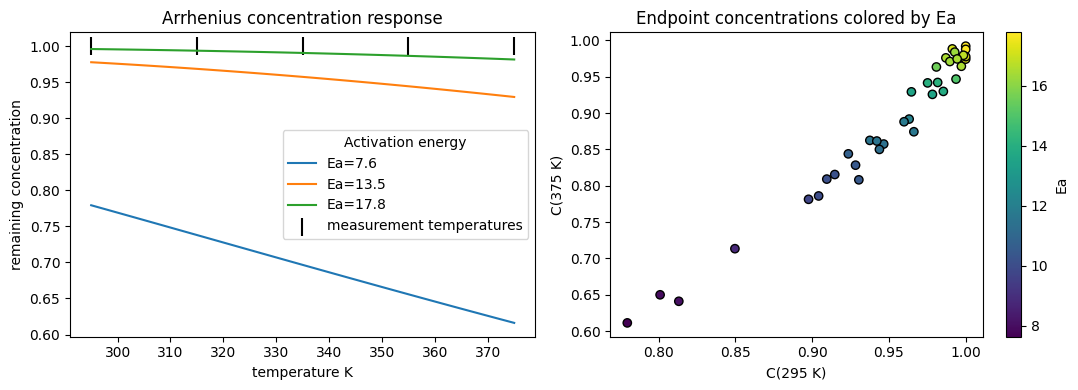

In [3]:
temperature_grid = np.linspace(temperatures.min(), temperatures.max(), 120)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ea in [activation_energy.min(), np.median(activation_energy), activation_energy.max()]:
    axes[0].plot(temperature_grid, concentration_trace(ea, temperature_grid), label=f"Ea={ea:.1f}")
axes[0].scatter(temperatures, np.ones_like(temperatures), marker="|", s=180, color="black", label="measurement temperatures")
axes[0].set_title("Arrhenius concentration response")
axes[0].set_xlabel("temperature K")
axes[0].set_ylabel("remaining concentration")
axes[0].legend(title="Activation energy")
scatter = axes[1].scatter(concentrations[:, 0], concentrations[:, -1], c=activation_energy, cmap="viridis", edgecolor="black")
axes[1].set_title("Endpoint concentrations colored by Ea")
axes[1].set_xlabel(f"C({temperatures[0]:.0f} K)")
axes[1].set_ylabel(f"C({temperatures[-1]:.0f} K)")
fig.colorbar(scatter, ax=axes[1], label="Ea")
plt.tight_layout()
plt.show()


## Package-client inverse models

In [4]:
qgpr = QuantumGaussianProcessRegressor(QuantumKernel(embedding="iqp", seed=831), alpha=1e-3)
qgpr.fit(x_train, y_train)
qgpr_energy_pred = y_scaler.inverse_transform(qgpr.predict(x_test).reshape(-1, 1)).ravel()

qkr = QuantumKernelRegressor(QuantumKernel(embedding="zz", seed=832), alpha=2e-3)
qkr.fit(x_train, y_train)
qkr_energy_pred = y_scaler.inverse_transform(qkr.predict(x_test).reshape(-1, 1)).ravel()

ridge = Ridge(alpha=1e-2)
ridge.fit(x_train, y_train)
ridge_energy_pred = y_scaler.inverse_transform(ridge.predict(x_test).reshape(-1, 1)).ravel()

results = {
    "quantum_gpr_activation_energy_mae": mean_absolute_error(ea_test, qgpr_energy_pred),
    "quantum_kernel_activation_energy_mae": mean_absolute_error(ea_test, qkr_energy_pred),
    "ridge_activation_energy_mae": mean_absolute_error(ea_test, ridge_energy_pred),
    "quantum_gpr_activation_energy_mse": mean_squared_error(ea_test, qgpr_energy_pred),
}

print_section(
    "Results",
    [
        ("Quantum GPR Ea MAE", results["quantum_gpr_activation_energy_mae"]),
        ("Quantum kernel Ea MAE", results["quantum_kernel_activation_energy_mae"]),
        ("Ridge Ea MAE", results["ridge_activation_energy_mae"]),
    ],
)


Results
+-----------------------+----------+
| Metric                | Value    |
+-----------------------+----------+
| Quantum GPR Ea MAE    | 0.416631 |
| Quantum kernel Ea MAE | 0.424169 |
| Ridge Ea MAE          | 0.793175 |
+-----------------------+----------+



## Plots

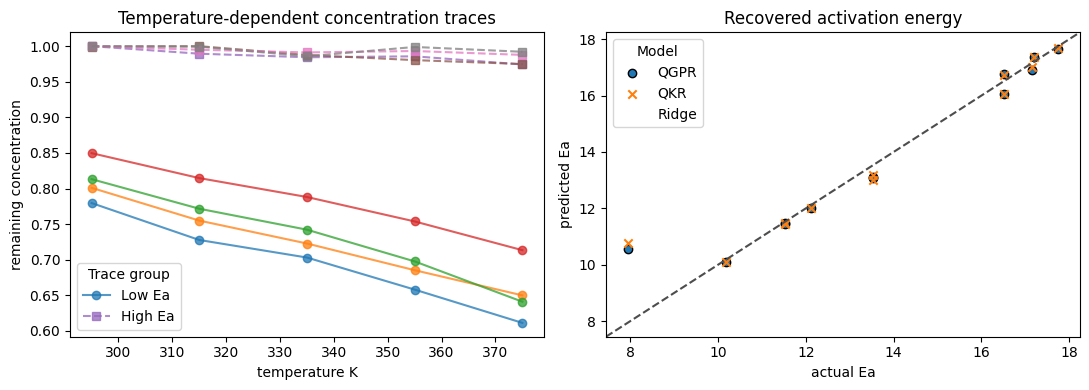

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
low_ea = np.argsort(activation_energy)[:4]
high_ea = np.argsort(activation_energy)[-4:]
for pos, idx in enumerate(low_ea):
    axes[0].plot(temperatures, concentrations[idx], "o-", alpha=0.75, label="Low Ea" if pos == 0 else None)
for pos, idx in enumerate(high_ea):
    axes[0].plot(temperatures, concentrations[idx], "s--", alpha=0.75, label="High Ea" if pos == 0 else None)
axes[0].set_title("Temperature-dependent concentration traces")
axes[0].set_xlabel("temperature K")
axes[0].set_ylabel("remaining concentration")
axes[0].legend(title="Trace group")

low = min(ea_test.min(), qgpr_energy_pred.min(), qkr_energy_pred.min(), ridge_energy_pred.min()) - 0.5
high = max(ea_test.max(), qgpr_energy_pred.max(), qkr_energy_pred.max(), ridge_energy_pred.max()) + 0.5
axes[1].scatter(ea_test, qgpr_energy_pred, label="QGPR", edgecolor="black")
axes[1].scatter(ea_test, qkr_energy_pred, marker="x", label="QKR")
axes[1].scatter(ea_test, ridge_energy_pred, marker="s", facecolors="none", label="Ridge")
axes[1].plot([low, high], [low, high], "--", color="0.3")
axes[1].set_xlim(low, high)
axes[1].set_ylim(low, high)
axes[1].set_title("Recovered activation energy")
axes[1].set_xlabel("actual Ea")
axes[1].set_ylabel("predicted Ea")
axes[1].legend(title="Model")
plt.tight_layout()
plt.show()


## Validation block

In [6]:
validation = {
    "dataset": {
        "problem": "arrhenius_activation_energy_inference",
        "n_train": int(len(ea_train)),
        "n_test": int(len(ea_test)),
        "feature_count": int(x_train.shape[1]),
    },
    "results": results,
    "sample_predictions": [
        {"actual_activation_energy": float(a), "quantum_gpr_energy": float(g), "quantum_kernel_energy": float(k)}
        for a, g, k in zip(ea_test[:6], qgpr_energy_pred[:6], qkr_energy_pred[:6])
    ],
    "passed": bool(
        np.isfinite(qgpr_energy_pred).all()
        and np.isfinite(qkr_energy_pred).all()
        and results["quantum_gpr_activation_energy_mae"] < 2.5
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:5])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------------+---------------------------------------+
| Metric        | Value                                 |
+---------------+---------------------------------------+
| problem       | arrhenius_activation_energy_inference |
| n_train       | 26                                    |
| n_test        | 12                                    |
| feature_count | 5                                     |
+---------------+---------------------------------------+

Results
+--------------------------------------+----------+
| Metric                               | Value    |
+--------------------------------------+----------+
| quantum_gpr_activation_energy_mae    | 0.416631 |
| quantum_kernel_activation_energy_mae | 0.424169 |
| ridge_activation_energy_mae          | 0.793175 |
| quantum_gpr_activation_energy_mse    | 0.637986 |
+--------------------------------------+----------+

Sample predictions
+--------------------------+--------------------+-----------------------